In [137]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
import datetime as dt
import matplotlib.ticker as tck

In [3]:
LOG_DIR = Path('/g/data/gb02/public/dashboard/pag548')

Load the default case with no I/O server

In [76]:
default = LOG_DIR / 'AM3_N512_no_ioserver.log'

In [77]:
# Read line by line if dealing with JSON lines
with open(default, 'r') as file:
    data = [json.loads(line) for line in file]

In [222]:
df = pd.json_normalize(data)

In [235]:
df['time'] = pd.to_datetime(df.t, unit = 's')
df['time_elapsed'] = df['time'] - df['time'].iloc[0]
df['seconds'] = df['time_elapsed'].dt.total_seconds()  # Required for sensible plotting
df.set_index('time_elapsed',inplace=True)

In [236]:
from matplotlib.ticker import FuncFormatter

# 1. The formatter now expects 'x' to be plain seconds (float)
def format_seconds_to_hms(x, pos):
    hours, remainder = divmod(x, 3600)
    minutes, seconds = divmod(remainder, 60)
    # Handles sub-second precision accurately
    return f"{int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}"

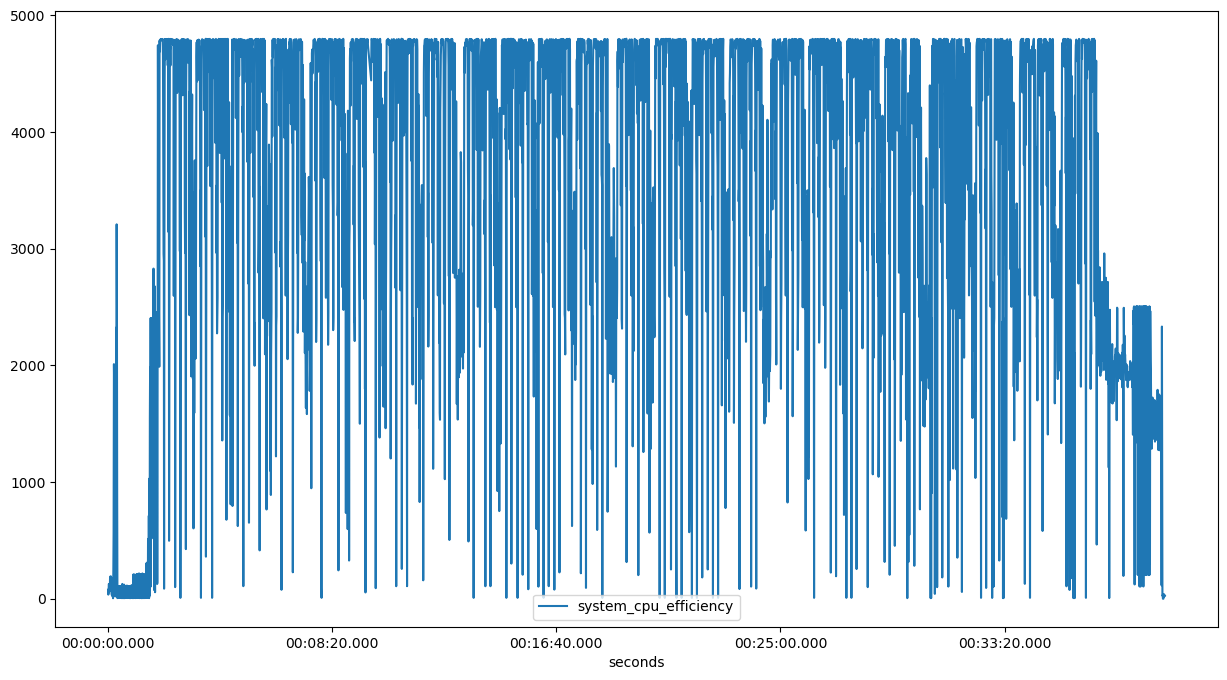

In [237]:
fig,ax = plt.subplots(figsize=(15,8))
df.set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))


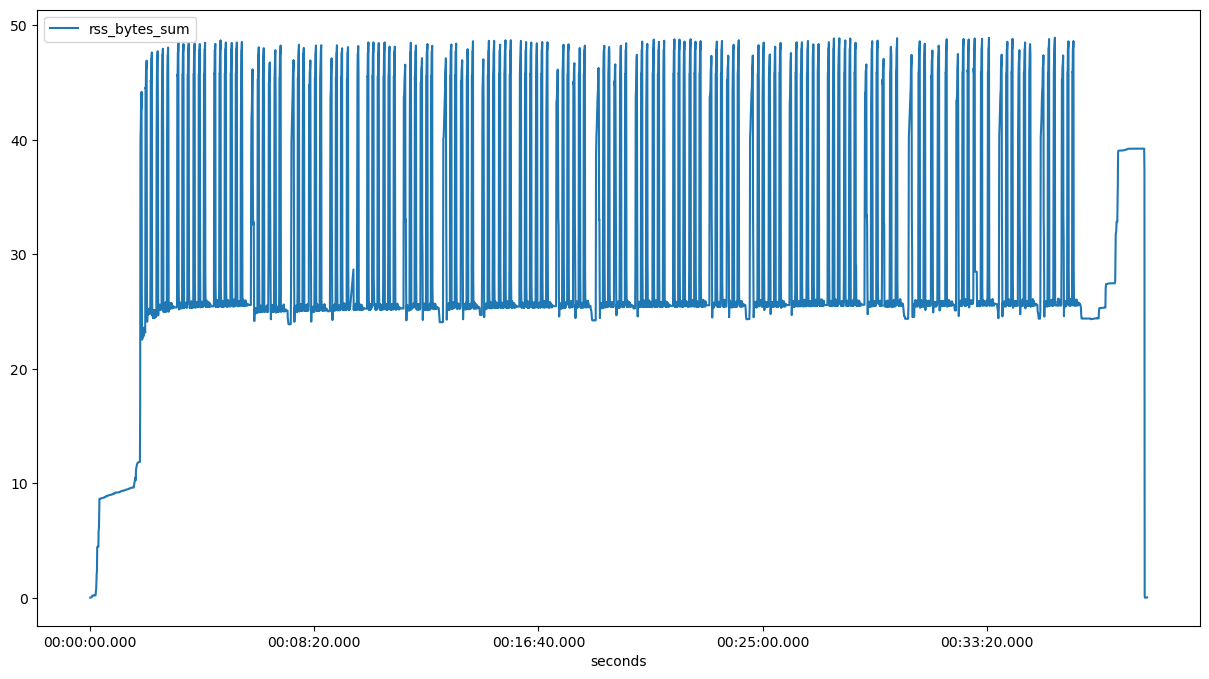

In [234]:
fig,ax = plt.subplots(figsize=(15,8))
(df.set_index('seconds')[['rss_bytes_sum']]/1e9).plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))

In [228]:
df.index[0:5]

TimedeltaIndex([          '0 days 00:00:00', '0 days 00:00:00.554999828',
                '0 days 00:00:01.108999967', '0 days 00:00:01.661999941',
                '0 days 00:00:02.248999834'],
               dtype='timedelta64[ns]', name='time_elapsed', freq=None)

In [200]:
df.index[-10:]

Index([2352.455999851, 2353.000999927, 2353.544999838, 2354.090999841,
       2354.637999773, 2355.184999942,  2355.72999978, 2356.278999805,
        2356.82799983, 2357.375999927],
      dtype='float64', name='seconds')

In [239]:
df.loc[pd.Timedelta('0.5 seconds'):pd.Timedelta('1.5 seconds')]

KeyError: Timedelta('0 days 00:00:00.500000')

In [238]:
df.loc[pd.Timedelta('40 seconds'):pd.Timedelta('50 seconds')]

KeyError: Timedelta('0 days 00:00:40')

In [207]:
pd.Timedelta('00:01:20')

Timedelta('0 days 00:01:20')

In [101]:
a = pd.DataFrame({'blob': range(5)},index=pd.TimedeltaIndex(["0 days", "1 days", "2 days", "3 days", "4 days"]))

In [102]:
a

,blob
0 days,0
1 days,1
2 days,2
3 days,3
4 days,4


In [103]:
a.index

TimedeltaIndex(['0 days', '1 days', '2 days', '3 days', '4 days'], dtype='timedelta64[ns]', freq=None)

In [106]:
a.loc['1 days':'3 days']

,blob
1 days,1
2 days,2
3 days,3


In [108]:
a.loc[pd.Timedelta('1 days'):pd.Timedelta('3 days')]

,blob
1 days,1
2 days,2
3 days,3


In [210]:
b = pd.DataFrame({'blob': range(5)},index=df.time_elapsed.iloc[:5])

In [211]:
b

,blob
time_elapsed,
0 days 00:00:00,0
0 days 00:00:00.554999828,1
0 days 00:00:01.108999967,2
0 days 00:00:01.661999941,3
0 days 00:00:02.248999834,4


In [215]:
ix = b.loc[pd.Timedelta('0.5 seconds'):pd.Timedelta('1.5 seconds')]

In [216]:
ix

,blob
time_elapsed,
0 days 00:00:00.554999828,1
0 days 00:00:01.108999967,2


In [232]:
df.set_index('seconds')['system_cpu_efficiency']

seconds
0.000              NaN
0.555        77.093437
1.109        35.849629
1.662        43.836520
2.249       127.050395
               ...    
2355.185     39.556332
2355.730     31.642641
2356.279     19.322760
2356.828     24.897577
2357.376     26.417363
Name: system_cpu_efficiency, Length: 3761, dtype: float64